**Table of contents**<a id='toc0_'></a>

- [Import Libraries](#toc1_1_)
  - [Get Data](#toc1_2_)

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->


## <a id='toc1_1_'></a>[Import Libraries](#toc0_)


In [1]:
import pandas as pd
import numpy as np

# stats
from scipy.stats import gaussian_kde

# visualization
import matplotlib.pyplot as plt

# get data from TradingView
from tvDatafeed import TvDatafeed, Interval
from enum import Enum

tv = TvDatafeed()

you are using nologin method, data you access may be limited


In [2]:
class TimeFrame(Enum):
    DAILY = "daily"
    YEARLY = "yearly"


class Method(Enum):
    PERCENTAGE = "pct"
    HLO = "hlo"  # (high - low) / close

## <a id='toc1_2_'></a>[Get Data](#toc0_)


In [6]:
interval = Interval.in_monthly

data = tv.get_hist(symbol="USOUSD", exchange="VANTAGE", interval=interval, n_bars=10_000)
data

,symbol,open,high,low,close,volume
datetime,,,,,,
2014-02-03 06:00:00,VANTAGE:USOUSD,96.932,102.789,96.736,101.609,0.0
2014-03-03 06:00:00,VANTAGE:USOUSD,99.135,101.204,98.883,100.992,0.0
2014-04-01 05:00:00,VANTAGE:USOUSD,99.203,103.146,98.768,100.259,0.0
2014-05-01 05:00:00,VANTAGE:USOUSD,103.599,104.049,103.373,103.949,0.0
2014-06-02 05:00:00,VANTAGE:USOUSD,103.816,105.286,103.527,105.143,0.0
...,...,...,...,...,...,...
2024-02-01 06:00:00,VANTAGE:USOUSD,75.863,79.729,71.356,78.401,0.0
2024-03-01 06:00:00,VANTAGE:USOUSD,78.408,83.564,76.830,83.435,0.0
2024-04-01 05:00:00,VANTAGE:USOUSD,83.576,87.802,81.106,81.780,0.0


In [16]:
START_YEAR = 2021
END_YEAR = 2024

# filtered year
filtered_data = data[(data.index.year >= START_YEAR) & (data.index.year <= END_YEAR)]

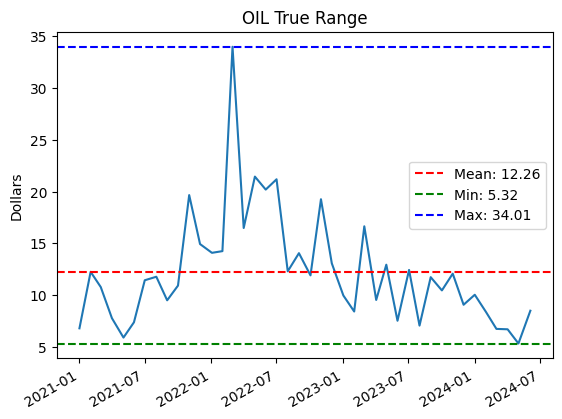

In [25]:
# Calculating the difference between 'high' and 'low'
diff = filtered_data["high"] - filtered_data["low"]

# Plotting the difference
diff.plot()

# Customizing the y-axis label
plt.ylabel('Dollars')

# Hiding the x-axis label
plt.xlabel('')

# Adding the title
plt.title("OIL True Range")

# Calculating the mean, min, and max of the difference
mean_value = diff.mean()
min_value = diff.min()
max_value = diff.max()

# Plotting the mean, min, and max as horizontal lines
plt.axhline(y=mean_value, color='r', linestyle='--', label=f'Mean: {mean_value:.2f}')
plt.axhline(y=min_value, color='g', linestyle='--', label=f'Min: {min_value:.2f}')
plt.axhline(y=max_value, color='b', linestyle='--', label=f'Max: {max_value:.2f}')

# Adding a legend
plt.legend(loc='center right')

# Display the plot
plt.show()

- Time value of Money
- 1 year เสียโอกาสเท่าไร
- 1d เสียโอกาสเท่าไร
- swap